# Weather RNN

CREDIT FOR PROJECT STRUCTURE: https://github.com/LukeDitria/pytorch_tutorials/blob/main/section12_sequential/solutions/Pytorch2_Autoregressive_RNN.ipynb


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset
import torch.nn.functional as F

from tqdm.notebook import trange, tqdm

import sys
sys.path.insert(0, "../src")
from Dataset import WeatherDataset, FEATURE_COLUMNS


## Data setup

In [ ]:
# Path to the CSV 
dataset_file = "../data/boston_weather_data_2.csv"

split_date = pd.to_datetime("2025-11-01")

# Number of days in the input sequence 
day_range = 15

# Number of days the model actually predicts
days_in = 14

# Ensure that the total number of days in the input sequence is larger than days_in
assert day_range > days_in, "The total day range must be larger than the input days"

# Hyperparameters
learning_rate = 1e-4
nepochs = 500
batch_size = 32


In [ ]:
dataset_train = WeatherDataset(dataset_file, day_range=day_range, split_date=split_date, train_test="train")
dataset_test = WeatherDataset(dataset_file, day_range=day_range, split_date=split_date, train_test="test")

print(f"Number of training examples: {len(dataset_train)}")
print(f"Number of testing examples: {len(dataset_test)}")
print(f"Features (in order): {FEATURE_COLUMNS}")


Number of training examples: 474
Number of testing examples: 167
Features (in order): ['hum', 'uvi', 'tavg', 'wspd', 'wdir', 'pres', 'prcp']


In [ ]:
data_loader_train = DataLoader(dataset=dataset_train, batch_size=batch_size, shuffle=True, drop_last=True)
data_loader_test = DataLoader(dataset=dataset_test, batch_size=batch_size, shuffle=False, drop_last=True)


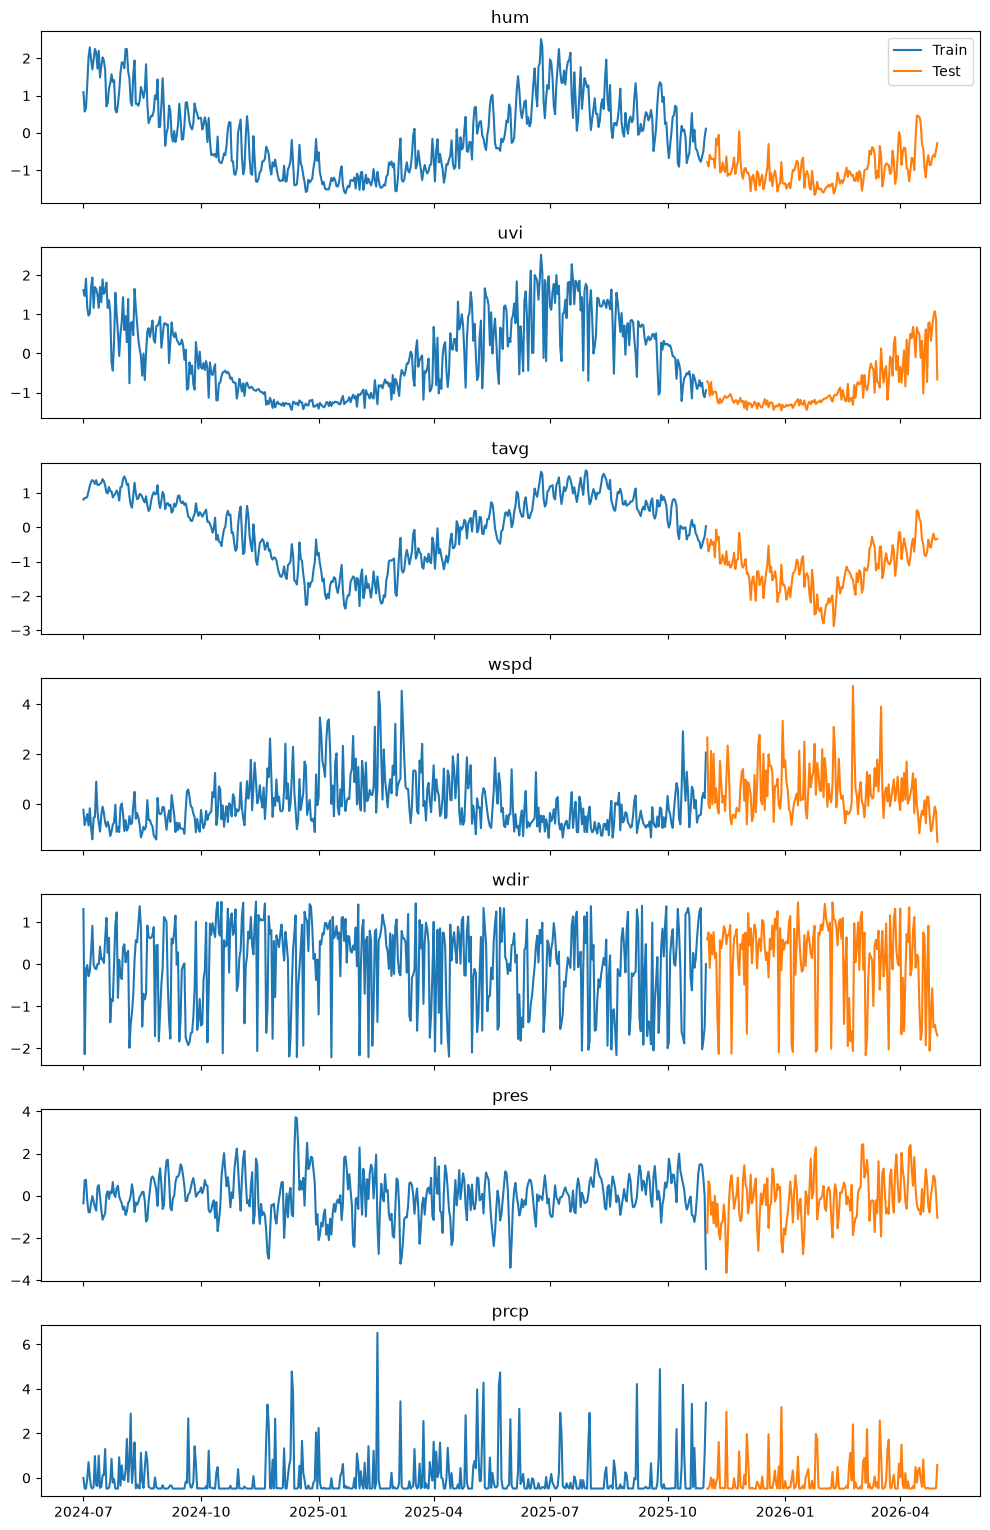

In [ ]:
fig, axes = plt.subplots(len(FEATURE_COLUMNS), 1, figsize=(10, 2.2 * len(FEATURE_COLUMNS)), sharex=True)

for i, col in enumerate(FEATURE_COLUMNS):
    axes[i].plot(dataset_train.dates, dataset_train.dataset[col].values)
    axes[i].plot(dataset_test.dates, dataset_test.dataset[col].values)
    axes[i].set_title(col)

axes[0].legend(["Train", "Test"])
plt.tight_layout()
plt.show()


## Create RNN Network

In [ ]:
class ResBlockMLP(nn.Module):
    def __init__(self, input_size, output_size):
        super(ResBlockMLP, self).__init__()
        # Layer normalization for the input
        self.norm1 = nn.LayerNorm(input_size)
        # First fully connected layer that reduces the dimensionality by half
        self.fc1 = nn.Linear(input_size, input_size // 2)

        # Layer normalization after the first fully connected layer
        self.norm2 = nn.LayerNorm(input_size // 2)
        # Second fully connected layer that outputs the desired output size
        self.fc2 = nn.Linear(input_size // 2, output_size)

        # Skip connection layer to match the output size
        self.fc3 = nn.Linear(input_size, output_size)

        # Activation function
        self.act = nn.ELU()

    def forward(self, x):
        # Apply normalization and activation function to the input
        x = self.act(self.norm1(x))
        # Compute the skip connection output
        skip = self.fc3(x)

        # Apply the first fully connected layer, normalization, and activation function
        x = self.act(self.norm2(self.fc1(x)))
        # Apply the second fully connected layer
        x = self.fc2(x)

        # Add the skip connection to the output
        return x + skip


class RNN(nn.Module):
    def __init__(self, seq_len, n_features, num_blocks=1, buffer_size=128):
        super(RNN, self).__init__()

        # Flattened length of the input window (days * features per day)
        seq_data_len = seq_len * n_features

        # Input MLP: flattened window -> 128-dim vector
        self.input_mlp = nn.Sequential(
            nn.Linear(seq_data_len, 4 * seq_data_len),
            nn.ELU(),
            nn.Linear(4 * seq_data_len, 128),
            nn.ELU()
        )

        # RNN step: concatenates the input vector with the buffer and feeds it through a linear layer
        self.rnn = nn.Linear(256, 128)

        # Residual blocks
        blocks = [ResBlockMLP(128, 128) for _ in range(num_blocks)]
        self.res_blocks = nn.Sequential(*blocks)

        # Output head: predicts the next day's features
        self.fc_out = nn.Linear(128, n_features)

        # Buffer head: carries information forward to the next time-step
        self.fc_buffer = nn.Linear(128, buffer_size)

        self.act = nn.ELU()

    def forward(self, input_seq, buffer_in):
        # Reshape the input window to a flat vector
        input_seq = input_seq.reshape(input_seq.shape[0], -1)
        input_vec = self.input_mlp(input_seq)

        # Concatenate the previous step's buffer with the input vector
        x_cat = torch.cat((buffer_in, input_vec), 1)

        # Pass through the RNN linear layer
        x = self.rnn(x_cat)

        # Pass through residual blocks
        x = self.act(self.res_blocks(x))

        # Predicted next-day features, and the updated buffer
        return self.fc_out(x), torch.tanh(self.fc_buffer(x))


In [ ]:
# Set device to GPU if available, otherwise CPU
device = torch.device(0 if torch.cuda.is_available() else "cpu")

buffer_size = 128
n_features = len(FEATURE_COLUMNS)

weather_rnn = RNN(seq_len=days_in, n_features=n_features, buffer_size=buffer_size).to(device)

optimizer = optim.Adam(weather_rnn.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

training_loss_logger = []


In [ ]:
num_model_params = 0
for param in weather_rnn.parameters():
    num_model_params += param.flatten().shape[0]

print("-This Model Has %d (Approximately %d Million) Parameters!" % (num_model_params, num_model_params // 1e6))


-This Model Has 172895 (Approximately 0 Million) Parameters!


## Training

In [ ]:
for epoch in trange(nepochs, desc="Epochs", leave=False):
    weather_rnn.train()

    for day, month, data_seq in tqdm(data_loader_train, desc="Training", leave=False):
        # Input window: first `days_in` days
        seq_block = data_seq[:, :days_in].to(device)

        # Zero-initialized buffer at the start of each sequence
        buffer = torch.zeros(data_seq.shape[0], buffer_size, device=device)

        loss = 0

        # Roll forward over the remaining days in the window, feeding predictions back in
        for i in range(day_range - days_in):
            target_seq_block = data_seq[:, i + days_in].to(device)

            data_pred, buffer = weather_rnn(seq_block, buffer)

            loss += loss_fn(data_pred, target_seq_block)

            # Slide the window: drop oldest day, append the (detached) prediction
            seq_block = torch.cat((seq_block[:, 1:, :], data_pred.unsqueeze(1).detach()), 1)

        loss /= i + 1

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        training_loss_logger.append(loss.item())


Epochs:   0%|          | 0/500 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

...

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

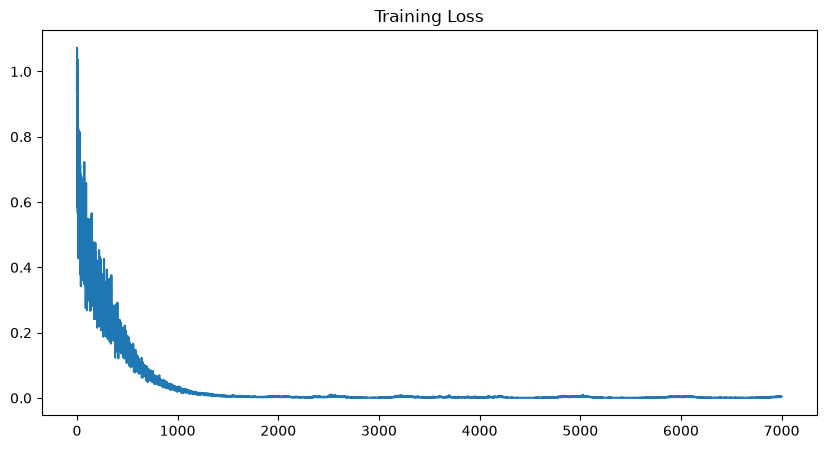

In [ ]:
_ = plt.figure(figsize=(10, 5))
_ = plt.plot(training_loss_logger)
_ = plt.title("Training Loss")


## Testing

### Predicting with Feedback

Autoregressive roll-out on the test set: seed with the first `days_in` real days, then keep predicting forward using the model's own previous outputs.


In [ ]:
data_tensor = dataset_test.values  # already normalized, [n_days, n_features]

log_predictions = []

weather_rnn.eval()

with torch.no_grad():
    seq_block = data_tensor[:days_in, :].unsqueeze(0).to(device)
    buffer = torch.zeros(seq_block.shape[0], buffer_size, device=device)

    for i in range(data_tensor.shape[0] - days_in):
        data_pred, buffer = weather_rnn(seq_block, buffer)
        log_predictions.append(data_pred.cpu())

        seq_block = torch.cat((seq_block[:, 1:, :], data_pred.unsqueeze(1)), 1)

predictions_cat = torch.cat(log_predictions)

# Unnormalize using the TRAIN mean/std (that's what both datasets were normalized with)
un_norm_predictions = (predictions_cat * dataset_test.std) + dataset_test.mean
un_norm_data = (data_tensor * dataset_test.std) + dataset_test.mean

# Trim the seed days so it lines up with the predictions
un_norm_data = un_norm_data[days_in:]


Test MSE value 2107.7334
  hum   : 36.9460
  uvi   : 1.3938
  tavg  : 289.9165
  wspd  : 2.1719
  wdir  : 14377.7305
  pres  : 0.8281
  prcp  : 45.1460


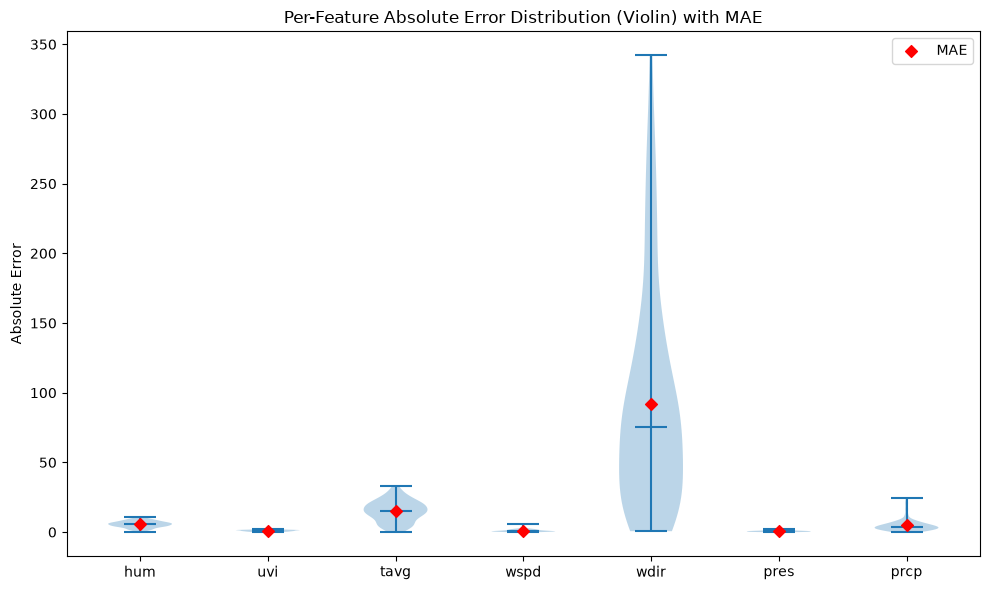

MAE per feature:
  hum   : 5.6040
  uvi   : 1.0340
  tavg  : 15.1965
  wspd  : 1.1289
  wdir  : 91.7528
  pres  : 0.7292
  prcp  : 4.9606


In [ ]:
test_mse = (un_norm_data - un_norm_predictions).pow(2).mean().item()
print("Test MSE value %.4f" % test_mse)

# Per-feature MSE is more informative since the features are on very different scales
per_feature_mse = (un_norm_data - un_norm_predictions).pow(2).mean(dim=0)
for name, val in zip(FEATURE_COLUMNS, per_feature_mse.tolist()):
    print(f"  {name:6s}: {val:.4f}")


abs_errors = (un_norm_data - un_norm_predictions).abs()  # [n_days, n_features]
mae_per_feature = abs_errors.mean(dim=0)

fig, ax = plt.subplots(figsize=(10, 6))

violin_data = [abs_errors[:, i].numpy() for i in range(len(FEATURE_COLUMNS))]
positions = np.arange(1, len(FEATURE_COLUMNS) + 1)

parts = ax.violinplot(violin_data, positions=positions, showmeans=False, showmedians=True)

ax.scatter(positions, mae_per_feature.numpy(), color="red", zorder=3, label="MAE", marker="D")

ax.set_xticks(positions)
ax.set_xticklabels(FEATURE_COLUMNS)
ax.set_ylabel("Absolute Error")
ax.set_title("Per-Feature Absolute Error Distribution (Violin) with MAE")
ax.legend()
plt.tight_layout()
plt.show()

print("MAE per feature:")
for name, val in zip(FEATURE_COLUMNS, mae_per_feature.tolist()):
    print(f"  {name:6s}: {val:.4f}")

### 2-Week Forecast: Predictions vs Ground Truth

Same autoregressive test-set algorithm as the cell above (seed on the first `days_in` days of
`dataset_test`, then roll forward) — just capped to `PRED_DAYS` steps instead of the whole test set,
so it's easy to see the first 2 weeks clearly.


In [ ]:
# ── Same algorithm as the test-set cell above, just capped to PRED_DAYS steps ──
PRED_DAYS = 14   # how many days to predict and compare against ground truth

data_tensor_2wk = dataset_test.values  # already normalized, [n_days, n_features]

log_preds_full = []
weather_rnn.eval()

with torch.no_grad():
    seq_block_full = data_tensor_2wk[:days_in, :].unsqueeze(0).to(device)
    buffer_full = torch.zeros(seq_block_full.shape[0], buffer_size, device=device)

    n_steps = min(PRED_DAYS, data_tensor_2wk.shape[0] - days_in)
    for i in range(n_steps):
        pred_step, buffer_full = weather_rnn(seq_block_full, buffer_full)
        log_preds_full.append(pred_step.cpu())
        seq_block_full = torch.cat((seq_block_full[:, 1:, :], pred_step.unsqueeze(1)), 1)

preds_full_cat = torch.cat(log_preds_full)

# Unnormalize using the TRAIN mean/std (same as the cell above)
un_norm_preds_full = (preds_full_cat * dataset_test.std) + dataset_test.mean
un_norm_gt_full     = (data_tensor_2wk[days_in:days_in + n_steps, :] * dataset_test.std) + dataset_test.mean

plot_dates_full = list(dataset_test.dates[days_in:days_in + n_steps])

print(f'Prediction span: {plot_dates_full[0].date()} \u2192 {plot_dates_full[-1].date()}')
print(f'Total days plotted: {len(plot_dates_full)}')


Prediction span: 2025-11-15 → 2025-11-28
Total days plotted: 14


### QNN Inference (Temperature, Humidity, Wind Speed)

In [ ]:
import sys, os

project_root = os.path.abspath('..')   # notebooks/ -> project root
for p in (project_root, os.path.join(project_root, 'QNN')):
    if p not in sys.path:
        sys.path.append(p)

from qnn_temperature import qnn_temperature
from qnn_humidity import qnn_humidity
from qnn_wind_speed import qnn_wind_speed

# standardization.py reads the CSV via a project-root-relative path, so cd there temporarily
_notebook_cwd = os.getcwd()
os.chdir(project_root)

w_temp, forward = qnn_temperature()   # runs its own internal training loop (unchanged)
w_hum  = qnn_humidity()               # same
w_wspd = qnn_wind_speed()             # same

os.chdir(_notebook_cwd)               # restore cwd for the rest of the notebook

print('QNN weights ready:', w_temp.shape, w_hum.shape, w_wspd.shape)


TRAINING TEMPERATURE
DATES SAMPLE 0   2024-07-01
1   2024-07-02
2   2024-07-03
3   2024-07-04
4   2024-07-05
dtype: datetime64[us]
MEANS [9.16873684 6.49980451 2.62318797 9.18661654 9.20430075 9.22190977
 9.23640602 6.5093985  6.51631579 6.52374436 6.53403008 2.62490226
 2.62440602 2.62326316 2.6237594 ] 9.168736842105263 6.499804511278197 2.623187969924812
STANDARD DEVIATIONS [10.31298076  3.99793636  1.05879364 10.3232519  10.33289962 10.34249288
 10.35116645  4.00557318  4.00815779  4.00991804  4.01532954  1.05695592
  1.05724681  1.05793175  1.05767443] 10.312980764018645 3.997936361393723 1.0587936400385602
Z INPUT ARRAY SIZE (665, 15)
Z INPUT ARRAY SAMPLE [[ 1.3023648   2.33125159 -0.97581618  1.14919054  1.1135015   1.10979919
   1.06302937  1.59043443  0.94649074  0.85195149  1.37621828 -0.53446151
  -0.74193273 -0.95777744 -0.3628332 ]
 [ 1.45169117  2.60889483 -0.3052417   1.29933703  1.14640611  1.11076608
   1.10746881  2.32441179  1.58768306  0.9442227   0.84824169 -0.9791

In [ ]:
from data.standardization import load_and_prepare

_notebook_cwd = os.getcwd()
os.chdir(project_root)

(_X_scaled, _Ytemp, _Yhum, _Ywspd,
 tavgy_mean, tavgy_stdev, humy_mean, humy_stdev, wspdy_mean, wspdy_stdev,
 alphasx, alphasytemp, alphasyhum, alphasywspd, _dates) = load_and_prepare()

os.chdir(_notebook_cwd)

print('Scaling stats loaded (alphasx shape:', alphasx.shape, ')')


In [ ]:
from data.standardization import create_lag_features

# ── Rebuild the same raw lagged-feature table standardization.py builds internally,
#    so we have genuine (unscaled) day-to-day values plus real X_mean/X_std to scale with. ──
raw_df = pd.read_csv(dataset_file)   # dataset_file was defined earlier: '../data/boston_weather_data_2.csv'
raw_dates = pd.to_datetime(dict(year=raw_df['YEAR'], month=raw_df['MO'], day=raw_df['DY']))

qnn_base_features = ['tavg', 'hum', 'wspd']
qnn_lagged_df = create_lag_features(raw_df, qnn_base_features, lag_window=4).dropna()
qnn_lagged_cols = qnn_base_features + [f'{f}_lag{l}' for f in qnn_base_features for l in range(1, 5)]

X_raw   = qnn_lagged_df[qnn_lagged_cols].values          # [N-4, 15], real physical units
X_mean  = X_raw.mean(axis=0)
X_std   = X_raw.std(axis=0)
qnn_aligned_dates = raw_dates.loc[qnn_lagged_df.index].reset_index(drop=True)

def qnn_unscale(pred_scaled, meanY, stdevY, alphaY):
    return (pred_scaled / alphaY) * stdevY + meanY

# ── 2-week QNN forecast, matching the RNN's exact prediction window ──────────
# The RNN's forecast starts at dataset_test.dates[days_in] (after its own seed window),
# not right at split_date, so align the QNN's window to that same start date.
rnn_start_date = plot_dates_full[0]
split_idx = qnn_aligned_dates[qnn_aligned_dates >= rnn_start_date].index[0]
seed_len  = 5

window = X_raw[split_idx - seed_len:split_idx, :3].copy()   # last 5 real days before the window starts

qnn_pred_temp, qnn_pred_hum, qnn_pred_wspd = [], [], []

for step in range(PRED_DAYS):
    flat = window[::-1].flatten()          # newest-first: t, t-1, t-2, t-3, t-4
    x_in = ((flat - X_mean) / X_std) * alphasx

    t_s = forward(x_in, w_temp)
    h_s = forward(x_in, w_hum)
    w_s = forward(x_in, w_wspd)

    qnn_pred_temp.append(qnn_unscale(t_s, tavgy_mean, tavgy_stdev, alphasytemp))
    qnn_pred_hum.append(qnn_unscale(h_s, humy_mean, humy_stdev, alphasyhum))
    qnn_pred_wspd.append(qnn_unscale(w_s, wspdy_mean, wspdy_stdev, alphasywspd))

    next_row = np.array([qnn_pred_temp[-1], qnn_pred_hum[-1], qnn_pred_wspd[-1]])
    window = np.vstack([window[1:], next_row])   # slide the window forward

qnn_pred_dates = qnn_aligned_dates[split_idx:split_idx + PRED_DAYS].reset_index(drop=True)
qnn_truth_temp = X_raw[split_idx:split_idx + PRED_DAYS, 0]
qnn_truth_hum  = X_raw[split_idx:split_idx + PRED_DAYS, 1]
qnn_truth_wspd = X_raw[split_idx:split_idx + PRED_DAYS, 2]

print(f'QNN prediction span: {qnn_pred_dates.iloc[0].date()} -> {qnn_pred_dates.iloc[-1].date()}')
print(f'Total days predicted: {len(qnn_pred_dates)}')


In [ ]:
import matplotlib.dates as mdates

Y_LABELS = {
    'hum':  'Humidity (%)',
    'uvi':  'UV Index',
    'tavg': 'Temperature (\u00b0C)',
    'wspd': 'Wind Speed (m/s)',
    'wdir': 'Wind Direction (\u00b0)',
    'pres': 'Pressure (kPa)',
    'prcp': 'Precipitation (mm)',
}

fig, axes = plt.subplots(len(FEATURE_COLUMNS), 1,
                         figsize=(12, 2.5 * len(FEATURE_COLUMNS)), sharex=True)

# FEATURE_COLUMNS = ['hum', 'uvi', 'tavg', 'wspd', 'wdir', 'pres', 'prcp']
qnn_feature_map = {
    'hum':  qnn_pred_hum,
    'tavg': qnn_pred_temp,
    'wspd': qnn_pred_wspd,
}

for i, col in enumerate(FEATURE_COLUMNS):
    # Ground truth
    axes[i].plot(plot_dates_full, un_norm_gt_full[:, i].numpy(),
                 label='Ground Truth',   linewidth=1.6, color='steelblue', marker='o', markersize=3)
    # RNN prediction
    axes[i].plot(plot_dates_full, un_norm_preds_full[:, i].numpy(),
                 label='RNN Prediction', linewidth=1.3, alpha=0.85,
                 color='coral', linestyle='-', marker='o', markersize=3)
    # QNN prediction (only for tavg, hum, wspd)
    if col in qnn_feature_map:
        axes[i].plot(qnn_pred_dates, qnn_feature_map[col],
                     label='QNN Prediction', linewidth=1.3, alpha=0.85,
                     color='mediumseagreen', linestyle='--', marker='o', markersize=3)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel(Y_LABELS.get(col, col), fontsize=9)
    axes[i].grid(True, alpha=0.3)

# Daily date ticks — 14 days is short enough to label every day
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha='right')
axes[-1].set_xlabel('Date', fontsize=10)

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=9)

fig.suptitle(
    'RNN vs QNN — 2-Week Forecast vs Ground Truth\n'
    f'({plot_dates_full[0].strftime("%b %d, %Y")} - {plot_dates_full[-1].strftime("%b %d, %Y")})',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()


### Using Ground Truth First

Predicts the first 30 time steps grounded in real data (teacher forcing), then switches to the model's own predictions for the rest - gives the model more real context before it has to rely on itself.


In [ ]:
# # Uncomment to use!
# log_predictions = []
# weather_rnn.eval()
# buffer = torch.zeros(1, buffer_size, device=device)
#
# for i in range(30):
#     seq_block = data_tensor[i:(i + days_in), :].unsqueeze(0).to(device)
#     data_pred, buffer = weather_rnn(seq_block, buffer)
#     log_predictions.append(data_pred.cpu())
#
# for j in range(data_tensor.shape[0] - days_in - 30):
#     seq_block = torch.cat((seq_block[:, 1:, :], data_pred.unsqueeze(1)), 1)
#     data_pred, buffer = weather_rnn(seq_block, buffer)
#     log_predictions.append(data_pred.cpu())
#
# predictions_cat = torch.cat(log_predictions)
# un_norm_predictions = (predictions_cat * dataset_test.std) + dataset_test.mean
# un_norm_data = (data_tensor * dataset_test.std) + dataset_test.mean
# un_norm_data = un_norm_data[days_in:]
